In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time

In [30]:
import pandas as pd
train_df = pd.read_csv("D:\FruitDiseaseDissertation\processed_data\pv_train.csv")
val_df = pd.read_csv("D:\FruitDiseaseDissertation\processed_data\pv_val.csv")
test_df = pd.read_csv("D:\FruitDiseaseDissertation\processed_data\pv_test.csv")

<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
C:\Users\DELL\AppData\Local\Temp\ipykernel_23600\2871855030.py:2: SyntaxWarning: invalid escape sequence '\F'
  train_df = pd.read_csv("D:\FruitDiseaseDissertation\processed_data\pv_train.csv")
C:\Users\DELL\AppData\Local\Temp\ipykernel_23600\2871855030.py:3: SyntaxWarning: invalid escape sequence '\F'
  val_df = pd.read_csv("D:\FruitDiseaseDissertation\processed_data\pv_val.csv")
C:\Users\DELL\AppData\Local\Temp\ipykernel_23600\2871855030.py:4: SyntaxWarning: invalid escape sequence '\F'
  test_df = pd.read_csv("D:\FruitDiseaseDissertation\processed_data\pv_test.csv")


In [31]:
import pandas as pd
all_df = pd.concat([train_df,val_df,test_df])

class_names= sorted(all_df["class_name"].unique())
num_classes = len(class_names)

print("Number of classes:",num_classes)
print("Classes:",class_names)

Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_sp

In [32]:
print("Minimum label:", all_df["label"].min())
print("Maximum label:", all_df["label"].max())
print("Unique labels:", all_df["label"].nunique())

Minimum label: 0
Maximum label: 37
Unique labels: 38


In [33]:
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    return image, label

In [34]:
def make_dataset(df, training=False):

    paths = df["image_path"].values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [35]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [36]:
# normalizing only for the baseline CNN
normalization = layers.Rescaling(1./255)

In [37]:
num_classes = len(class_names)

model = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,662 (447.90 KB)

 Trainable params: 114,662 (447.90 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer ="adam",
    loss ="sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [39]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    ),

    keras.callbacks.ModelCheckpoint(
        filepath="../Models/baseline_cnn_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
    
]

In [40]:
import time

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

training_time = time.time() - start_time

print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/15


d:\FruitDiseaseDissertation\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2376/2376 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.3500 - loss: 2.2906
Epoch 1: val_loss improved from None to 1.44625, saving model to ../Models/baseline_cnn_best.keras

Epoch 1: finished saving model to ../Models/baseline_cnn_best.keras
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 954s 397ms/step - accuracy: 0.3500 - loss: 2.2906 - val_accuracy: 0.5760 - val_loss: 1.4462 - learning_rate: 0.0010
Epoch 2/15
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6175 - loss: 1.2701
Epoch 2: val_loss improved from 1.44625 to 1.02217, saving model to ../Models/baseline_cnn_best.keras

Epoch 2: finished saving model to ../Models/baseline_cnn_best.keras
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 803s 338ms/step - accuracy: 0.6175 - loss: 1.2701 - val_accuracy: 0.6853 - val_loss: 1.0222 - learning_rate: 0.0010
Epoch 3/15
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7156 - loss: 0.9208
Epoch 3: val_loss improved from 1.02217 to 0.70972, saving model to ../Models/baseline_cnn_best.keras

Epoch

In [28]:
import os

model_path = "../Models/baseline_cnn_best.keras"

print("Model will be saved to:")
print(os.path.abspath(model_path))

Model will be saved to:
d:\FruitDiseaseDissertation\Models\baseline_cnn_best.keras


In [41]:
import os

model_path = "../Models/baseline_cnn_best.keras"

print("Saved:", os.path.exists(model_path))
print("Location:", os.path.abspath(model_path))

Saved: True
Location: d:\FruitDiseaseDissertation\Models\baseline_cnn_best.keras


In [42]:
best_model = keras.models.load_model(
    "../Models/baseline_cnn_best.keras"
)

test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

510/510 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.9516 - loss: 0.1603
Test Loss: 0.16032448410987854
Test Accuracy: 0.9516326785087585


In [43]:
import numpy as np
from sklearn.metrics import classification_report


y_true = np.concatenate([y.numpy() for x, y in test_ds])


y_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

510/510 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.8936    0.8936    0.8936        94
                                 Apple___Black_rot     0.9362    0.9462    0.9412        93
                          Apple___Cedar_apple_rust     0.9000    0.8780    0.8889        41
                                   Apple___healthy     0.9500    0.9231    0.9363       247
                               Blueberry___healthy     0.9655    0.9956    0.9803       225
          Cherry_(including_sour)___Powdery_mildew     0.9560    0.9620    0.9590       158
                 Cherry_(including_sour)___healthy     0.8411    0.9922    0.9104       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7416    0.8571    0.7952        77
                       Corn_(maize)___Common_rust_     0.9833    0.9888    0.9861       179
               Corn_(maize)___North

In [45]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../report/baseline_cnn_classification_report.csv"
)

report_df

,precision,recall,f1-score,support
Apple___Apple_scab,0.893617,0.893617,0.893617,94.000000
Apple___Black_rot,0.936170,0.946237,0.941176,93.000000
Apple___Cedar_apple_rust,0.900000,0.878049,0.888889,41.000000
Apple___healthy,0.950000,0.923077,0.936345,247.000000
Blueberry___healthy,0.965517,0.995556,0.980306,225.000000
Cherry_(including_sour)___Powdery_mildew,0.955975,0.962025,0.958991,158.000000
Cherry_(including_sour)___healthy,0.841060,0.992188,0.910394,128.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.741573,0.857143,0.795181,77.000000
Corn_(maize)___Common_rust_,0.983333,0.988827,0.986072,179.000000
Corn_(maize)___Northern_Leaf_Blight,0.926471,0.851351,0.887324,148.000000


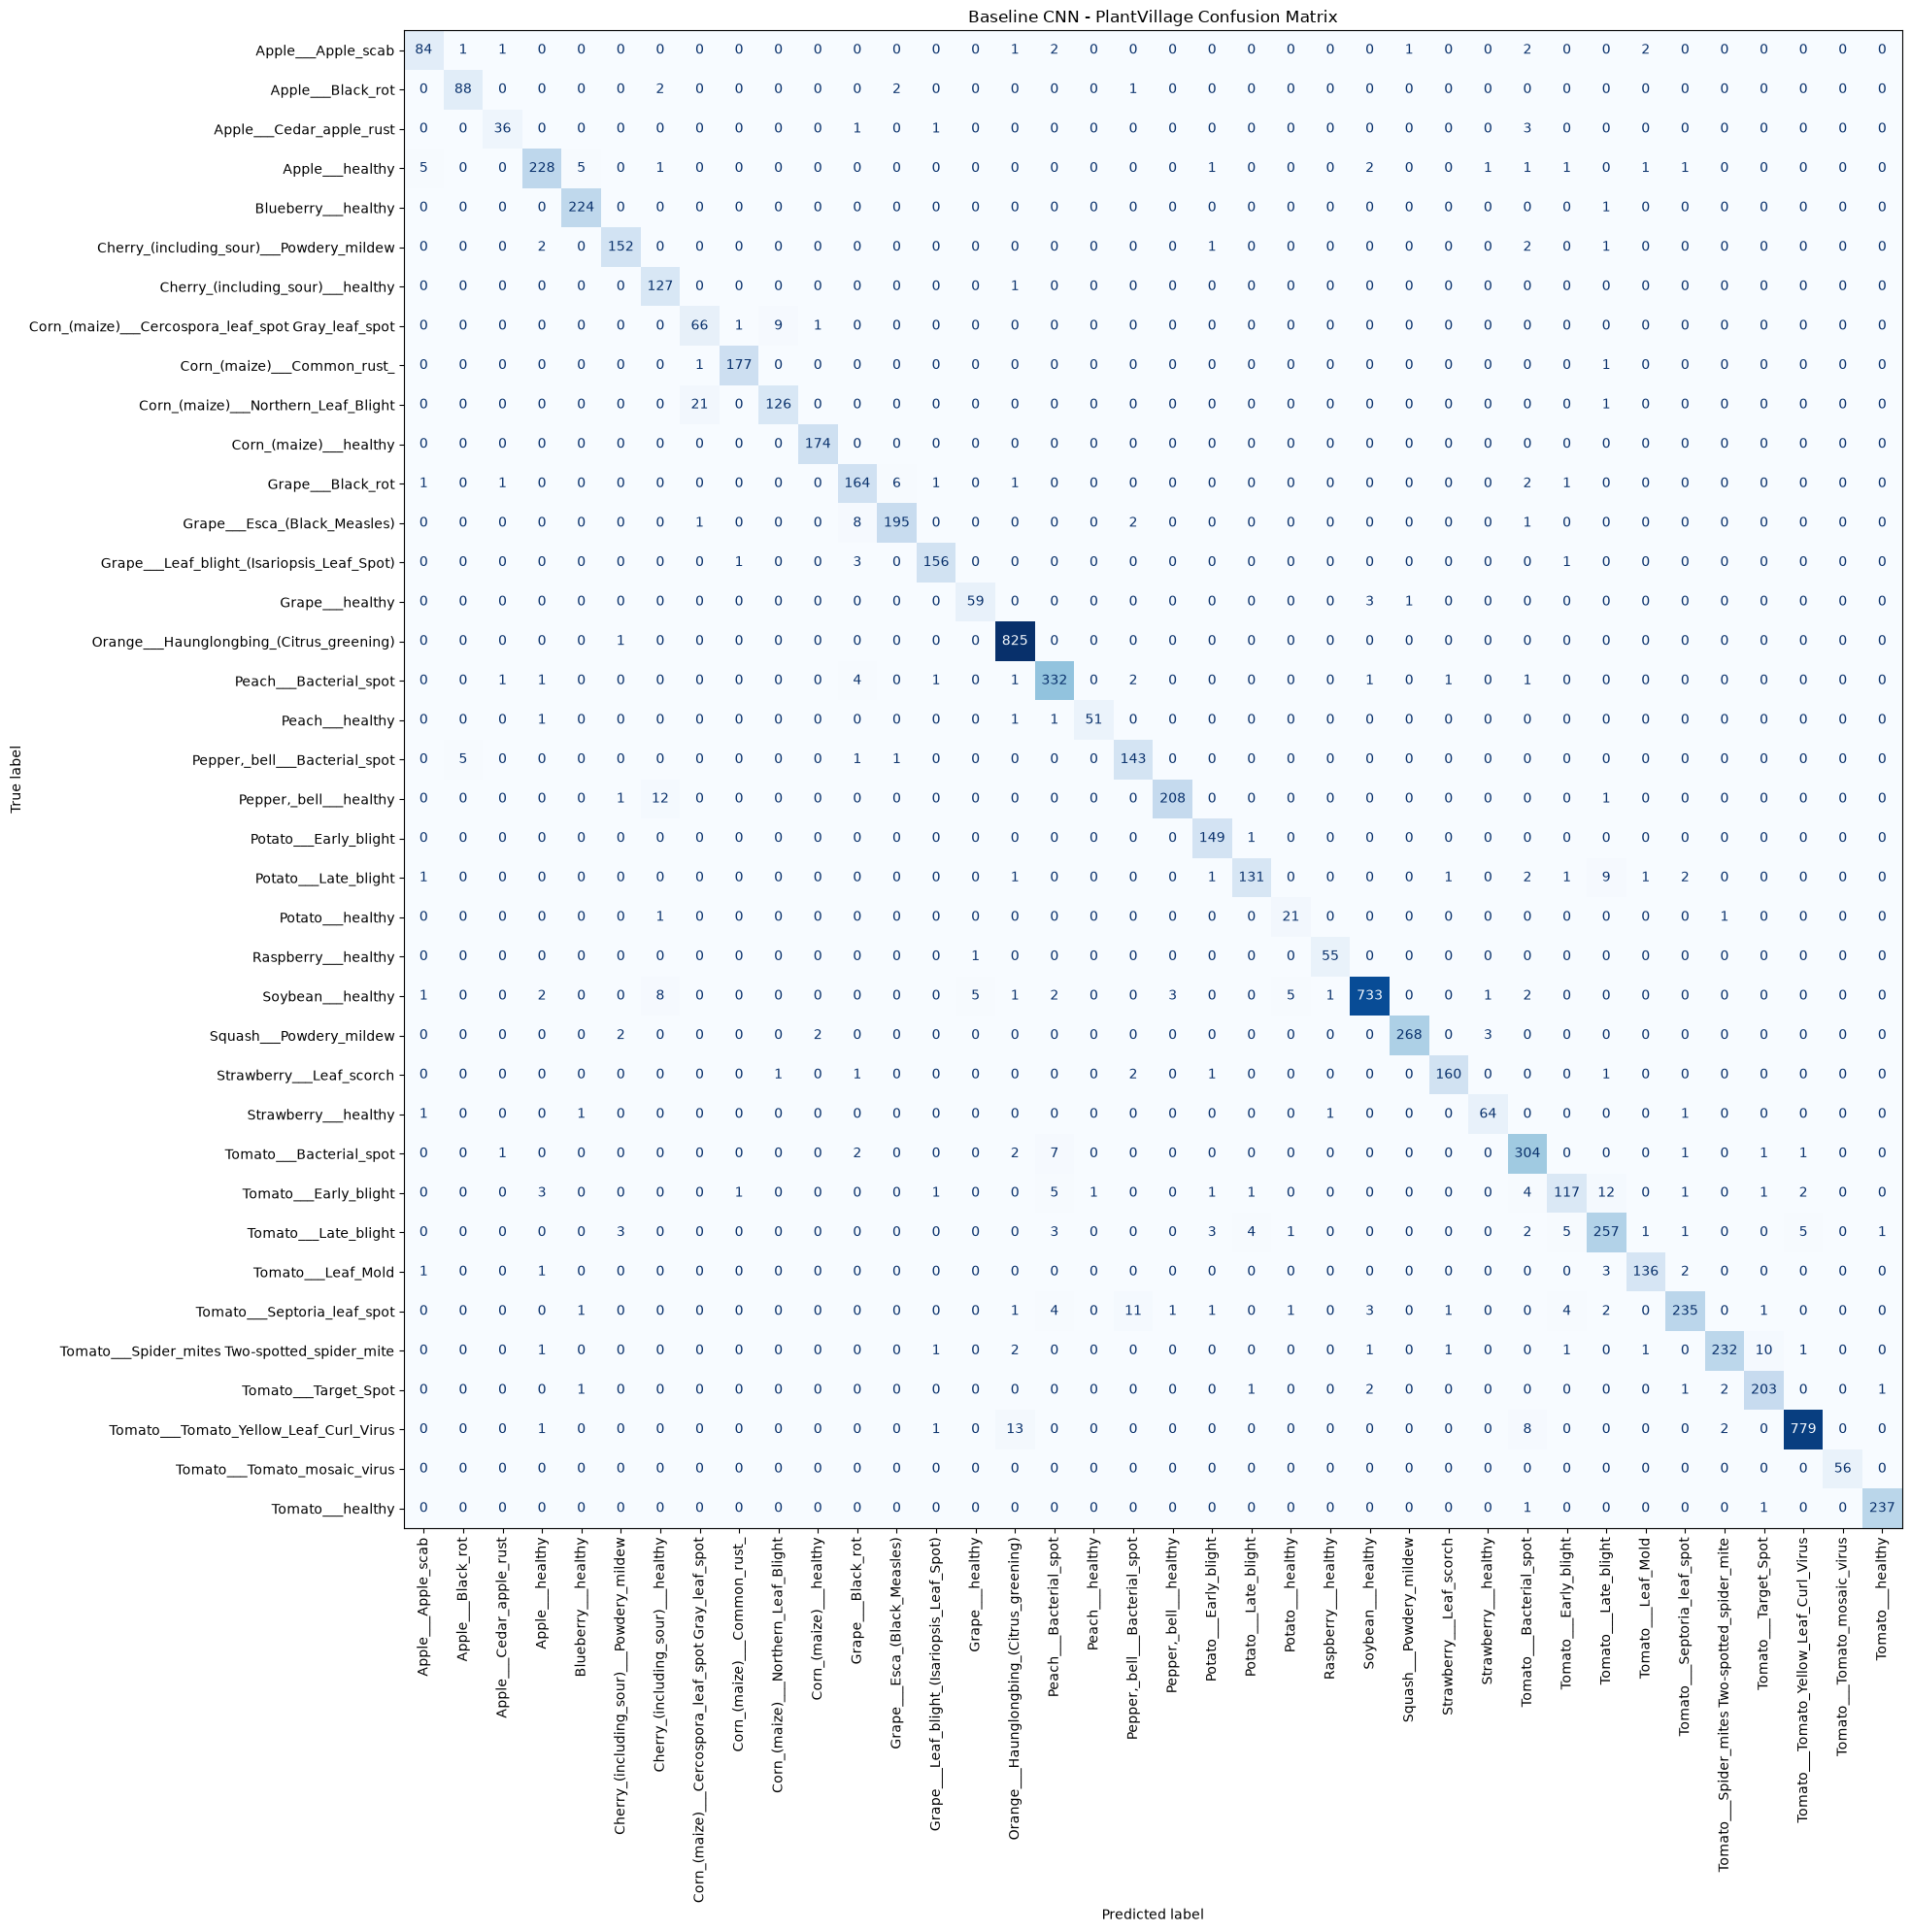

In [46]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("Baseline CNN - PlantVillage Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../report/baseline_cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

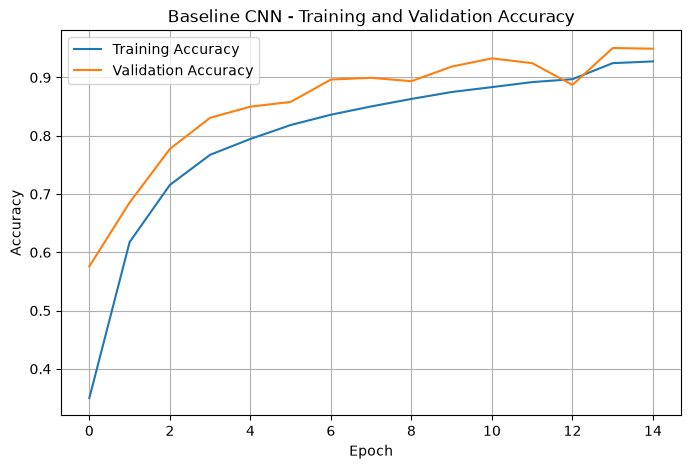

In [47]:
# accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "../report/baseline_cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

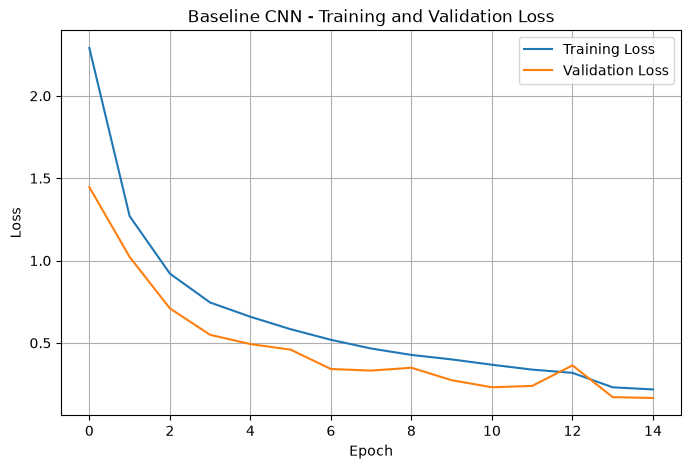

In [48]:
#loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "../report/baseline_cnn_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()